# Applied Data Science — Diwali Sales Data Analysis
**Module:** CC5061NI — Applied Data Science
**Assessment:** Individual Coursework (60% of module grade)
**Dataset:** Diwali Sales Transaction Data
**Semester:** Spring 2026

---


## 1. Library Imports

In [49]:
# 1. Core Data Manipulation & Numerical Computing
# Week 2, 3, 12 — fast numerical computing, ndarrays
import numpy as np 
# Week 3, 4, 10, 12 — DataFrame/Series, data wrangling
import pandas as pd         

# ── 2. Data Visualisation
# Week 5, 12 — static 2D plots
import matplotlib.pyplot as plt   
# Week 5 — render plots inline in notebook
%matplotlib inline      
import seaborn as sns

# ── 3. Statistics and Data Analysis
# Week 6 — mode, ANOVA, chi-square, skewness/kurtosis
from scipy import stats     

# ── 4. Machine Learning (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report
)
from sklearn import datasets

# ── 5. Web Scraping & Web Data
import requests
from bs4 import BeautifulSoup
from selenium import webdriver

# ── 6. Utility & System Operations
import os
import csv
import json
import time

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Data Understanding
### 2.1 — Identifying Data Sources, Types, and Potential Challenges
> The Diwali Sales Dataset contains customer transaction records from a Diwali sales
> campaign. Key aspects are explored below.

In [50]:
#loads csv file into dataframe
df = pd.read_csv('DiwaliSalesData_264932.csv', encoding='latin-1')

In [51]:
# shows  first 5 rows 
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [52]:
#Shows last 5 rows
df.tail()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN
11250,1002744,Brumley,P00281742,F,18-25,19,0,Maharashtra,Western,Healthcare,Office,3,188.0,NaN,NaN


In [53]:
# Check number of rows and columns
df.shape

(11251, 15)

In [54]:
# Show column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [55]:
#shows datatypes for all colummns
df.dtypes

User_ID               int64
Cust_name            object
Product_ID           object
Gender               object
Age Group            object
Age                   int64
Marital_Status        int64
State                object
Zone                 object
Occupation           object
Product_Category     object
Orders                int64
Amount              float64
Status              float64
unnamed1            float64
dtype: object

In [56]:
#this gives a variety of basic statistical values
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [57]:
# this counts missing values for columns present
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [58]:
# Memory used per column and total
df.memory_usage(deep=True)

Index                  132
User_ID              90008
Cust_name           622826
Product_ID          652371
Gender              562550
Age Group           606402
Age                  90008
Marital_Status       90008
State               680072
Zone                634242
Occupation          645544
Product_Category    700280
Orders               90008
Amount               90008
Status               90008
unnamed1             90008
dtype: int64

In [59]:
df.memory_usage(deep=True).sum()

np.int64(5734475)

# data prepreparation

In [60]:
# Reloading fresh before cleaning
df = pd.read_csv('DiwaliSalesData_264932.csv', encoding='latin-1')

In [61]:
df.shape

(11251, 15)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [63]:
#explaining each columns business relevence
print("""
Business Relevance of Key Variables:
 Amount          : Total sales revenue per transaction which is also the primary measure for sales
 Orders          : Number of items purchased at a time 
 Product_Category: Type of product sold to help identify top selling items
 Zone / State    : Geographic location of customer 
 Occupation      : Occupation of customer
 Gender          : Used for targeted marketing strategies
 Age Group       : Segments customers by life stage for analysis
 Marital_Status  : 0 = Unmarried and 1 = Married 
""")


Business Relevance of Key Variables:
 Amount          : Total sales revenue per transaction which is also the primary measure for sales
 Orders          : Number of items purchased at a time 
 Product_Category: Type of product sold to help identify top selling items
 Zone / State    : Geographic location of customer 
 Occupation      : Occupation of customer
 Gender          : Used for targeted marketing strategies
 Age Group       : Segments customers by life stage for analysis
 Marital_Status  : 0 = Unmarried and 1 = Married 



# data cleaning

In [64]:
#dropping columns which are not required
columns_to_drop = ['Cust_name', 'User_ID', 'unnamed1', 'Status']
df = df.drop(columns= columns_to_drop, errors='ignore')
df.columns.tolist()


['Product_ID',
 'Gender',
 'Age Group',
 'Age',
 'Marital_Status',
 'State',
 'Zone',
 'Occupation',
 'Product_Category',
 'Orders',
 'Amount']

In [65]:
df.shape

(11251, 11)

In [66]:
#this is for checking missing values while cleaning the data
df.isnull().sum()

Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [67]:
# Status was already dropped in columns_to_drop above
# Confirming it is not in the dataframe
print('Status' in df.columns)

False


In [68]:
#helps in dropping values where aamount and age is missing
df = df.dropna(subset=['Amount', 'Age'])

In [69]:
df.isnull().sum()

Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [70]:
# Confirm final row count
len(df)

11239

In [71]:
#Converting age groups
# Converting age groups
def age_group_mapping(age_group):
    if age_group == '0-17':
        return 'Teen'
    elif age_group in ['18-25', '26-35']:   
        return 'Adult'
    elif age_group in ['36-45', '46-50']:   
        return 'Middle-Aged'
    else:  # covers 51-55 and 55+
        return 'Senior'

In [72]:
df['Age_Group_Ordinal'] = df['Age Group'].map(age_group_mapping)

In [73]:
#ordering so Python knows the correct order
age_order = ['Teen', 'Adult', 'Middle-Aged', 'Senior']
df['Age_Group_Ordinal'] = pd.Categorical(
    df['Age_Group_Ordinal'],
    categories=age_order,
    ordered=True
)

In [74]:
# Verify mapping where it shows original vs new ordinal labels
df[['Age Group', 'Age_Group_Ordinal']].drop_duplicates().sort_values('Age_Group_Ordinal')

,Age Group,Age_Group_Ordinal
3,0-17,Teen
0,26-35,Adult
6,18-25,Adult
21,46-50,Middle-Aged
26,36-45,Middle-Aged
18,51-55,Senior
24,55+,Senior


In [75]:
#using 33rd and 66th as thresholds
low_threshold  = df['Amount'].quantile(0.33)
high_threshold = df['Amount'].quantile(0.66)

In [98]:
# Creating Purchase_Value_Category
# Creating Purchase_Value_Category
df['Purchase_Value_Category'] = pd.cut(
    df['Amount'],
    bins=[0, low_threshold, high_threshold, df['Amount'].max()],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

In [99]:
#this cuts the columns into medium, high and low based on the 33rd and 66th percentiles
df['Purchase_Value_Category'] = pd.Categorical(
    df['Purchase_Value_Category'],
    categories=['Low', 'Medium', 'High'],
    ordered=True
)

In [100]:
# Show how many transactions fall into each tier
df['Purchase_Value_Category'].value_counts()

Purchase_Value_Category
High      3821
Low       3712
Medium    3706
Name: count, dtype: int64

In [101]:
#counts the unique values and then shows the distint values 
categorical_cols = ['Gender', 'Age Group', 'Zone', 'State', 'Occupation', 'Product_Category', 'Marital_Status']

for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(unique_vals)


Gender (2 unique values):
['F' 'M']

Age Group (7 unique values):
['26-35' '0-17' '18-25' '51-55' '46-50' '55+' '36-45']

Zone (5 unique values):
['Western' 'Southern' 'Central' 'Northern' 'Eastern']

State (16 unique values):
['Maharashtra' 'Andhra\xa0Pradesh' 'Uttar Pradesh' 'Karnataka' 'Gujarat'
 'Himachal Pradesh' 'Delhi' 'Jharkhand' 'Kerala' 'Haryana'
 'Madhya Pradesh' 'Bihar' 'Rajasthan' 'Uttarakhand' 'Telangana' 'Punjab']

Occupation (15 unique values):
['Healthcare' 'Govt' 'Automobile' 'Construction' 'Food Processing'
 'Lawyer' 'Media' 'Banking' 'Retail' 'IT Sector' 'Aviation' 'Hospitality'
 'Agriculture' 'Textile' 'Chemical']

Product_Category (18 unique values):
['Auto' 'Hand & Power Tools' 'Stationery' 'Tupperware' 'Footwear & Shoes'
 'Furniture' 'Food' 'Games & Toys' 'Sports Products' 'Books'
 'Electronics & Gadgets' 'Decor' 'Clothing & Apparel' 'Beauty'
 'Household items' 'Pet Care' 'Veterinary' 'Office']

Marital_Status (2 unique values):
[0 1]


In [102]:
df.shape

(11239, 13)

In [103]:
df.head()

,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Age_Group_Ordinal,Purchase_Value_Category
0,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,Adult,High
1,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,Adult,High
2,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,Adult,High
3,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,Teen,High
4,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,Adult,High


# data analysis

In [104]:
# Summary statistics for the three main numeric columns
numerical_cols = ['Age', 'Orders', 'Amount']
 
summary_stats = pd.DataFrame({
    'Mean':     df[numerical_cols].mean(),
    'Median':   df[numerical_cols].median(),
    'Std Dev':  df[numerical_cols].std(),
    'Skewness': df[numerical_cols].skew(),
    'Kurtosis': df[numerical_cols].kurt()
})
print(summary_stats.round(4))

             Mean  Median    Std Dev  Skewness  Kurtosis
Age       35.4104    33.0    12.7539    1.1855    2.4720
Orders     2.4896     2.0     1.1150    0.0193   -1.3525
Amount  9453.6109  8109.0  5222.3559    0.5580   -0.5402


plot_skewness kurtosis


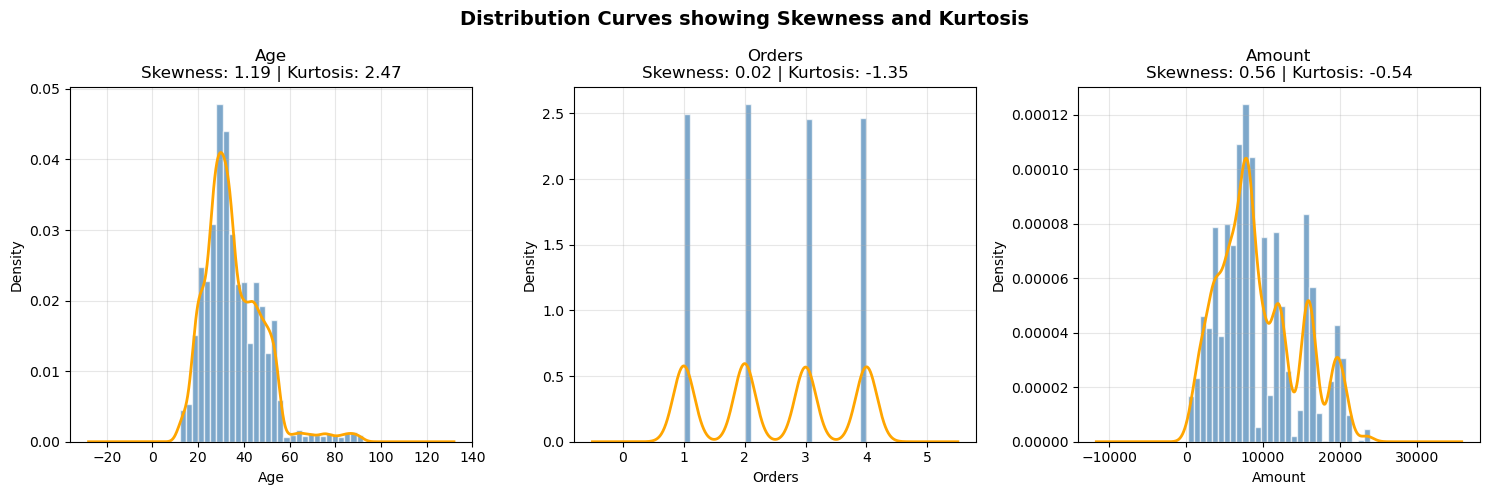

In [106]:
# Distribution curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribution Curves showing Skewness and Kurtosis', fontsize=14, fontweight='bold')
 
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', density=True, alpha=0.7)
    df[col].dropna().plot(kind='kde', ax=axes[i], color='orange', linewidth=2)
    skew_val = df[col].skew()
    kurt_val = df[col].kurt()
    axes[i].set_title(f'{col}\nSkewness: {skew_val:.2f} | Kurtosis: {kurt_val:.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('plot_skewness_kurtosis.png', dpi=150)
print("plot_skewness kurtosis")

In [107]:
# Pearson correlation between numeric columns which measures linaer relationjsip
corr_matrix = df[numerical_cols].corr(method='pearson')
print(corr_matrix.round(4))

           Age  Orders  Amount
Age     1.0000  0.0081  0.0309
Orders  0.0081  1.0000 -0.0132
Amount  0.0309 -0.0132  1.0000


In [85]:
# Spearman correlation
corr_spearman = df[numerical_cols].corr(method='spearman')
print(corr_spearman.round(4))

           Age  Orders  Amount
Age     1.0000  0.0070  0.0384
Orders  0.0070  1.0000 -0.0134
Amount  0.0384 -0.0134  1.0000


In [86]:
# Finding the strongest and weakest correlated variable pairs
corr_unstacked = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack()
max_pair = corr_unstacked.idxmax()
min_pair = corr_unstacked.idxmin()
print("Max correlation:", max_pair , "=", round(corr_unstacked.max(),4))
print("Min correlation:", min_pair , "=", round(corr_unstacked.min(),4))

Max correlation: ('Age', 'Amount') = 0.0309
Min correlation: ('Orders', 'Amount') = -0.0132


plot correlation heatmap


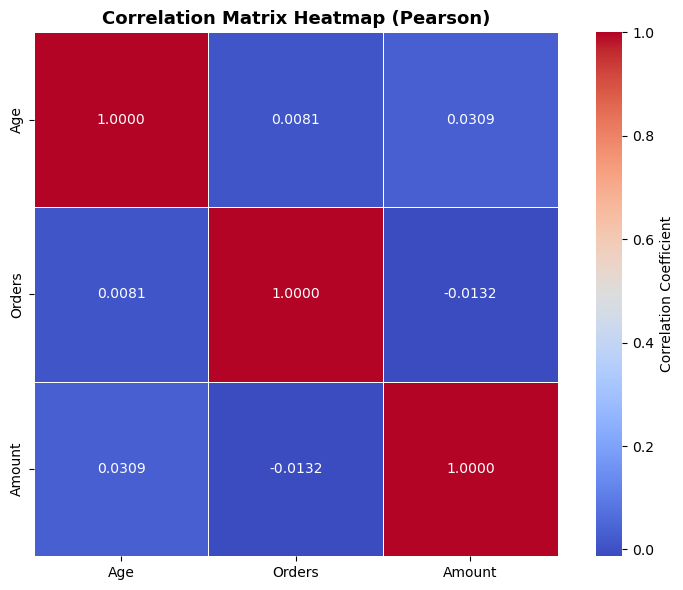

In [108]:
# Heatmap of the Pearson correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.4f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix Heatmap (Pearson)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=150)
print("plot correlation heatmap")

# data exploration

plot1_top5_states


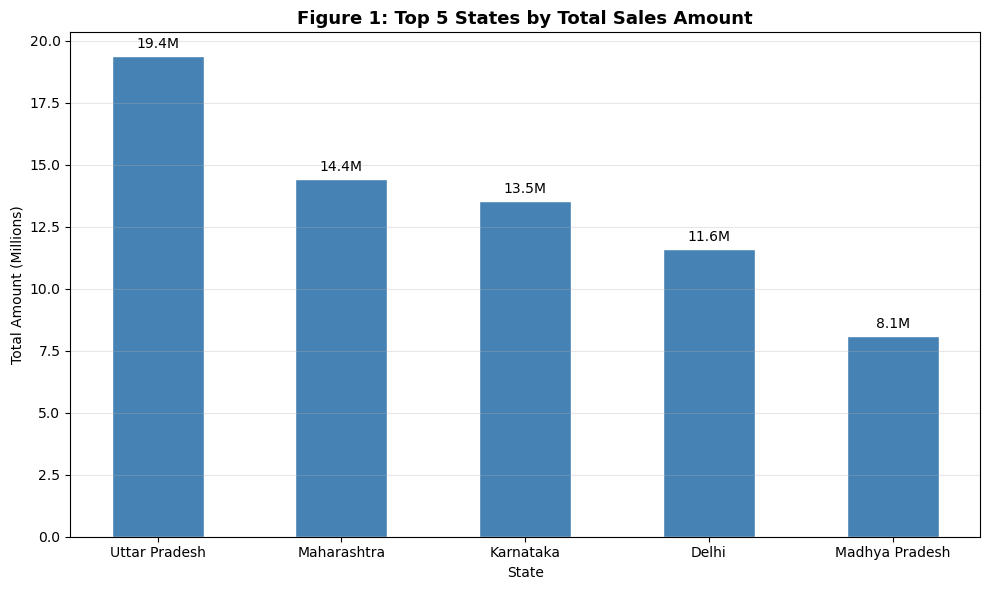

In [126]:
# Top 5 states by total sales Amount
top5_states = df.groupby('State')['Amount'].sum().nlargest(5).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(
    top5_states['State'],
    top5_states['Amount'] / 1e6,
    color='steelblue',
    edgecolor='white',
    width=0.5
)
plt.title('Figure 1: Top 5 States by Total Sales Amount', fontsize=13, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Amount (Millions)')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, top5_states['Amount'] / 1e6):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}M', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('plot1_top5_states.png', dpi=150)
print("plot1_top5_states")

plot2 gender product


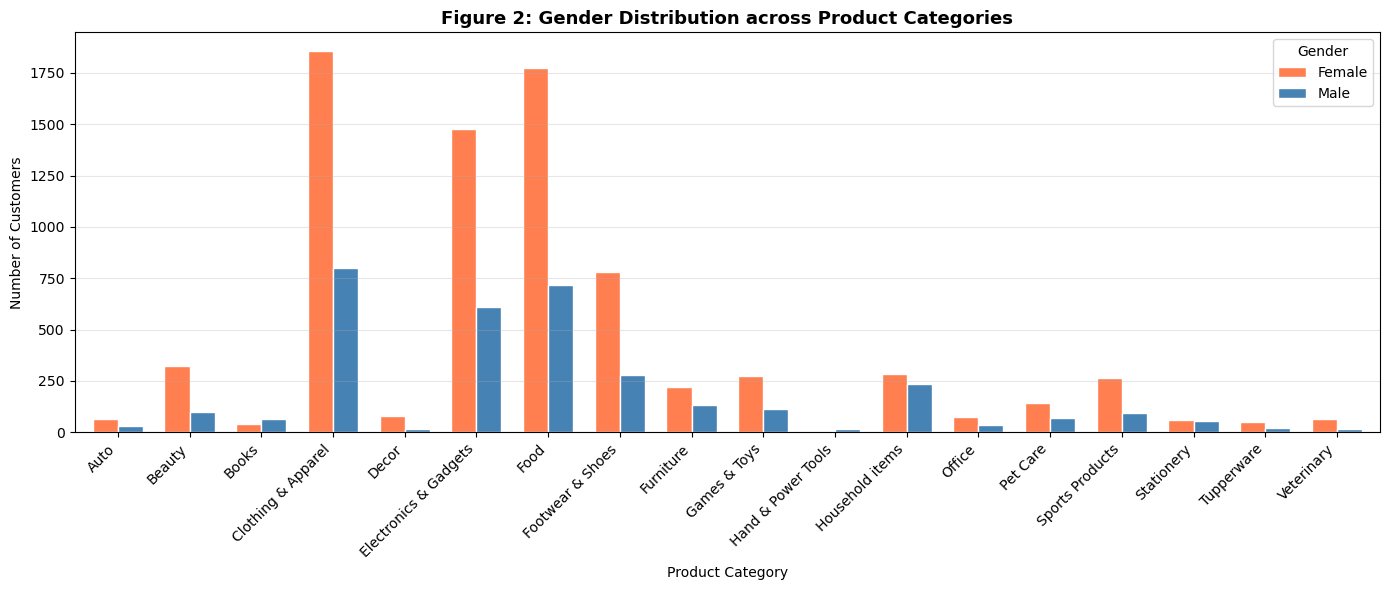

In [127]:
# Gender distribution across product categories
gender_product = df.groupby(['Product_Category', 'Gender']).size().unstack(fill_value=0)
 
gender_product.plot(
    kind='bar',
    figsize=(14, 6),
    color=['coral', 'steelblue'],
    edgecolor='white',
    width=0.7
)
plt.title('Figure 2: Gender Distribution across Product Categories', fontsize=13, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_gender_product.png', dpi=150)
print("plot2 gender product")

plot3_agegroup_amount


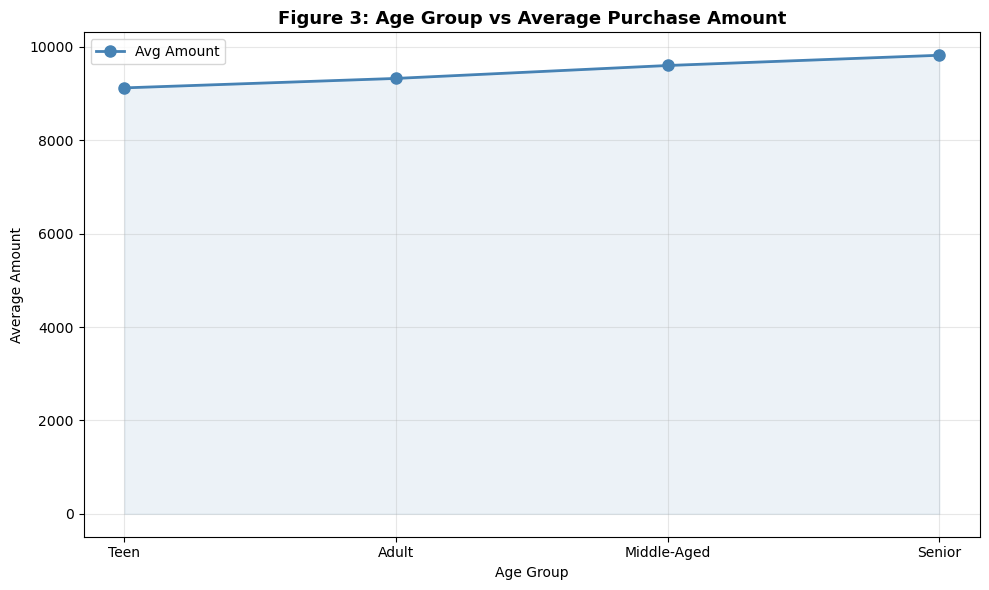

In [128]:
# Average Amount per Age Group using the ordinal categories defined in cleaning
age_amount = df.groupby('Age_Group_Ordinal', observed=True)['Amount'].mean().reset_index()
# Age_Group_Ordinal is ordered 
age_amount = age_amount.sort_values('Age_Group_Ordinal')

plt.figure(figsize=(10, 6))
plt.plot(
    age_amount['Age_Group_Ordinal'].astype(str),
    age_amount['Amount'],
    marker='o',
    color='steelblue',
    linewidth=2,
    markersize=8,
    label='Avg Amount'
)
plt.fill_between(range(len(age_amount)), age_amount['Amount'], alpha=0.1, color='steelblue')
plt.xticks(range(len(age_amount)), age_amount['Age_Group_Ordinal'].astype(str))
plt.title('Figure 3: Age Group vs Average Purchase Amount', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Amount')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_agegroup_amount.png', dpi=150)
print("plot3_agegroup_amount")

plot4 marital orders 


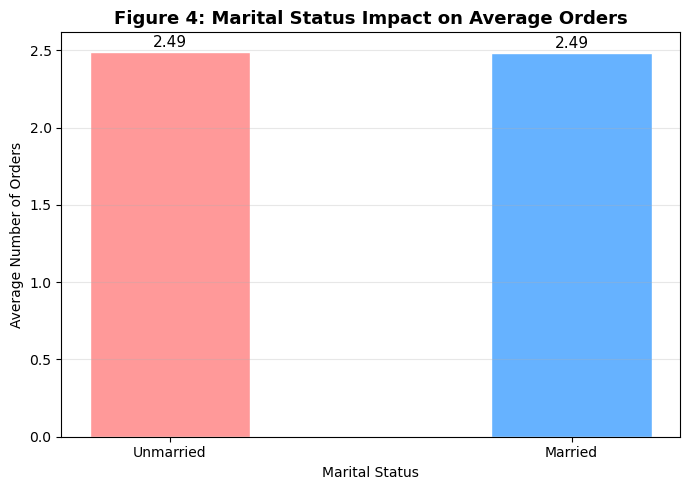

In [129]:
# Average orders placed by single vs married customers
marital_orders = df.groupby('Marital_Status')['Orders'].mean().reset_index()
marital_orders['Marital_Status'] = marital_orders['Marital_Status'].map({0: 'Unmarried', 1: 'Married'})
 
plt.figure(figsize=(7, 5))
bars = plt.bar(
    marital_orders['Marital_Status'],
    marital_orders['Orders'],
    color=['#FF9999', '#66B2FF'],
    edgecolor='white',
    width=0.4
)
plt.title('Figure 4: Marital Status Impact on Average Orders', fontsize=13, fontweight='bold')
plt.xlabel('Marital Status')
plt.ylabel('Average Number of Orders')
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, marital_orders['Orders']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('plot4_marital_orders.png', dpi=150)
print("plot4 marital orders ")

In [130]:
zone_product = df.groupby(['Zone', 'Product_Category'])['Amount'].mean().reset_index()

In [117]:
# Using all product categories (18 total)
zone_product_all = zone_product.copy()

In [118]:
zone_pivot = zone_product_all.pivot(index='Product_Category', columns='Zone', values='Amount')

plot5_zone_product


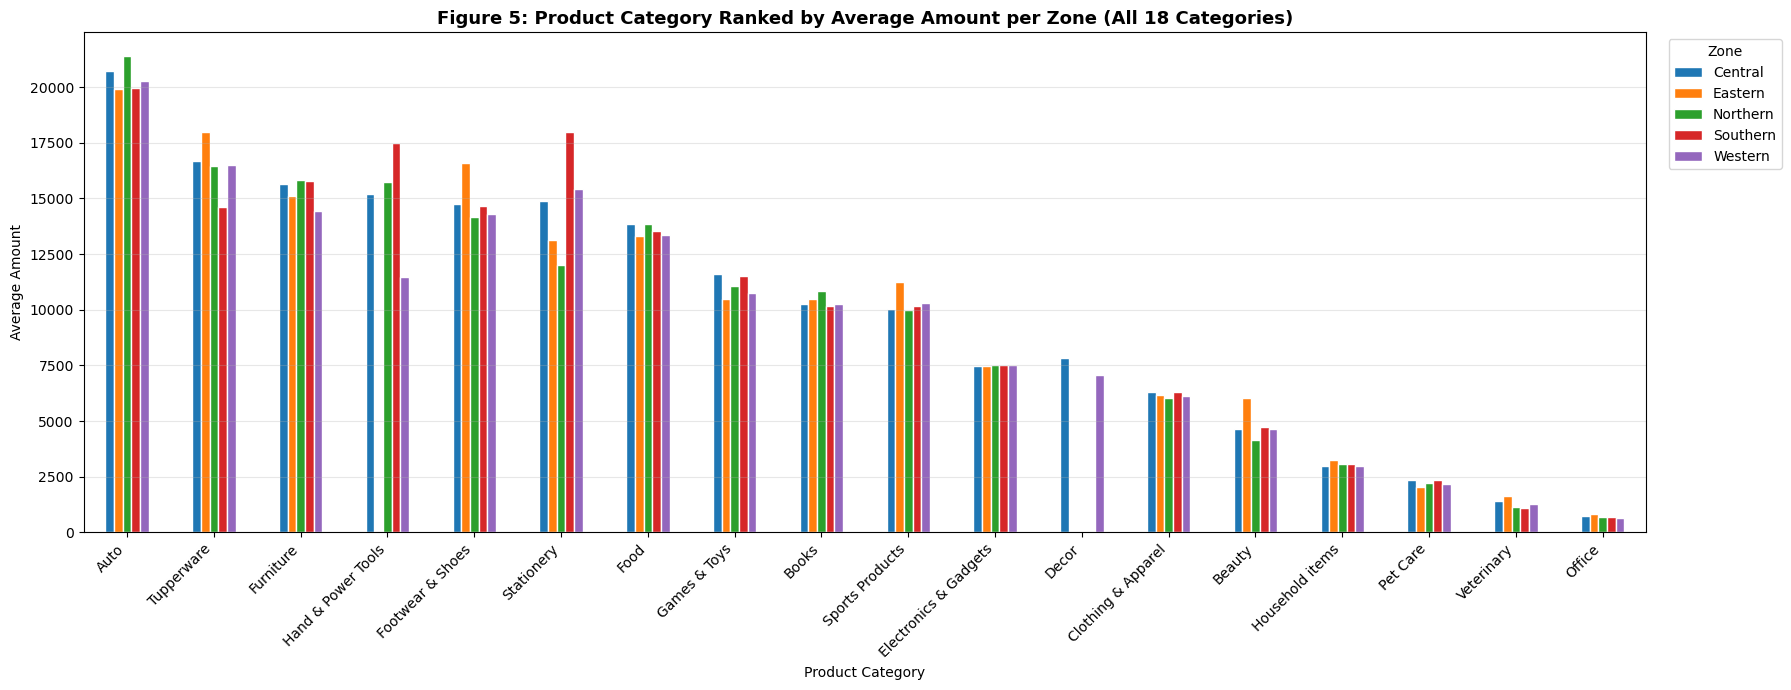

In [119]:
# Sort by average Amount across all zones
zone_pivot['Average'] = zone_pivot.mean(axis=1)
zone_pivot = zone_pivot.sort_values('Average', ascending=False).drop(columns='Average')

zone_pivot.plot(kind='bar', figsize=(18, 7), edgecolor='white')
plt.title('Figure 5: Product Category Ranked by Average Amount per Zone (All 18 Categories)',
          fontsize=13, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Average Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Zone', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot5_zone_product.png', dpi=150)
print("plot5_zone_product")

# Statistical testing

In [121]:
# Full descriptive statistics on the cleaned dataset before running statistical tests
df.describe(include='all')

,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Age_Group_Ordinal,Purchase_Value_Category
count,11239,11239,11239,11239.000000,11239.000000,11239,11239,11239,11239,11239.000000,11239.000000,11239,11239
unique,2350,2,7,NaN,NaN,16,5,15,18,NaN,NaN,4,3
top,P00265242,F,26-35,NaN,NaN,Uttar Pradesh,Central,IT Sector,Clothing & Apparel,NaN,NaN,Adult,High
freq,53,7832,4541,NaN,NaN,1944,4289,1583,2655,NaN,NaN,6420,3821
mean,NaN,NaN,NaN,35.410357,0.420055,NaN,NaN,NaN,NaN,2.489634,9453.610858,NaN,NaN
std,NaN,NaN,NaN,12.753866,0.493589,NaN,NaN,NaN,NaN,1.114967,5222.355869,NaN,NaN
min,NaN,NaN,NaN,12.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,188.000000,NaN,NaN
25%,NaN,NaN,NaN,27.000000,0.000000,NaN,NaN,NaN,NaN,2.000000,5443.000000,NaN,NaN
50%,NaN,NaN,NaN,33.000000,0.000000,NaN,NaN,NaN,NaN,2.000000,8109.000000,NaN,NaN
75%,NaN,NaN,NaN,43.000000,1.000000,NaN,NaN,NaN,NaN,3.000000,12675.000000,NaN,NaN


## Test 1

In [122]:
# Test 1 One-Way ANOVA
# H0: Mean Amount is equal across all occupation groups
# HA: Mean Amount differs significantly across at least one occupation group
# Spliting Amount into separate lists 
occupation_groups = [g['Amount'].values for _, g in df.groupby('Occupation')]
f_stat, p_anova = stats.f_oneway(*occupation_groups)
print(f"H0: Mean Amount is equal across all occupations.")
print(f"HA: Mean Amount differs significantly across occupations.")
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_anova:.6f}")
if p_anova < 0.05:
    print("Decision    : Reject H0 — significant difference in Amount across occupations.")
else:
    print("Decision    : Fail to reject H0.")


H0: Mean Amount is equal across all occupations.
HA: Mean Amount differs significantly across occupations.
F-statistic : 2.4771
p-value     : 0.001659
Decision    : Reject H0 — significant difference in Amount across occupations.


In [124]:
# Test 2 Chi-Square Test of Independence
# H0: Product_Category and Zone are independent (no association)
# HA: A significant association exists between Product_Category and Zone
# Building a contingency table

contingency = pd.crosstab(df['Product_Category'], df['Zone'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"H0: Product_Category and Zone are independent.")
print(f"HA: An association exists between Product_Category and Zone.")
print(f"Chi-square  : {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value     : {p_chi:.6e}")
if p_chi < 0.05:
    print("Decision    : Reject H0 — Product_Category and Zone are NOT independent.")
else:
    print("Decision    : Fail to reject H0.")


H0: Product_Category and Zone are independent.
HA: An association exists between Product_Category and Zone.
Chi-square  : 1634.9669
Degrees of freedom: 68
p-value     : 1.453612e-296
Decision    : Reject H0 — Product_Category and Zone are NOT independent.


In [8]:
tup1= (1,2,3)
tup2= (4,5,6)
print(tup1+tup2)
l=list(tup1)
l


(1, 2, 3, 4, 5, 6)


[1, 2, 3]